### Distribution Shapes - Skewness and Kurtosis Analysis

Measures how symmetrical each pollutant's distribution is.
All four pollutants are right-skewed - a few extreme days
create a long tail on the right side.

Key finding: SO2 is the most skewed (3.46) with kurtosis 26.
All four pollutants need log transform before Phase 8 modelling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data.csv", encoding="cp1252")
df.head()

,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [8]:
delhi = df[df["state"] == "Delhi"]
print(f"Delhi rows: {len(delhi)}")

Delhi rows: 8551


In [9]:
def compute_skewness(data):
    mean_val = np.mean(data)
    std_val  = np.std(data)

    standardized = (data - mean_val) / std_val
    skewness = np.mean(standardized ** 3)

    return skewness

In [10]:
def compute_kurtosis(data):
    mean_val = np.mean(data)
    std_val  = np.std(data)
    
    standardized = (data - mean_val) / std_val
    kurtosis = np.mean(standardized ** 4) - 3
    
    return kurtosis


In [11]:
pollutant_cols = ["pm2_5", "rspm", "no2", "so2"]

for col in pollutant_cols:
    data = delhi[col].dropna().values
    skew = compute_skewness(data)
    kurt = compute_kurtosis(data)
    print(f"{col}: skewness={skew:.2f}, kurtosis={kurt:.2f}")


pm2_5: skewness=1.31, kurtosis=2.71
rspm: skewness=1.17, kurtosis=1.63
no2: skewness=1.60, kurtosis=3.28
so2: skewness=3.46, kurtosis=26.01


In [12]:
print(f"SO2 zeros: {np.sum(delhi['so2'].dropna().values == 0)}")
print(f"SO2 min: {delhi['so2'].dropna().min()}")

SO2 zeros: 0
SO2 min: 0.5


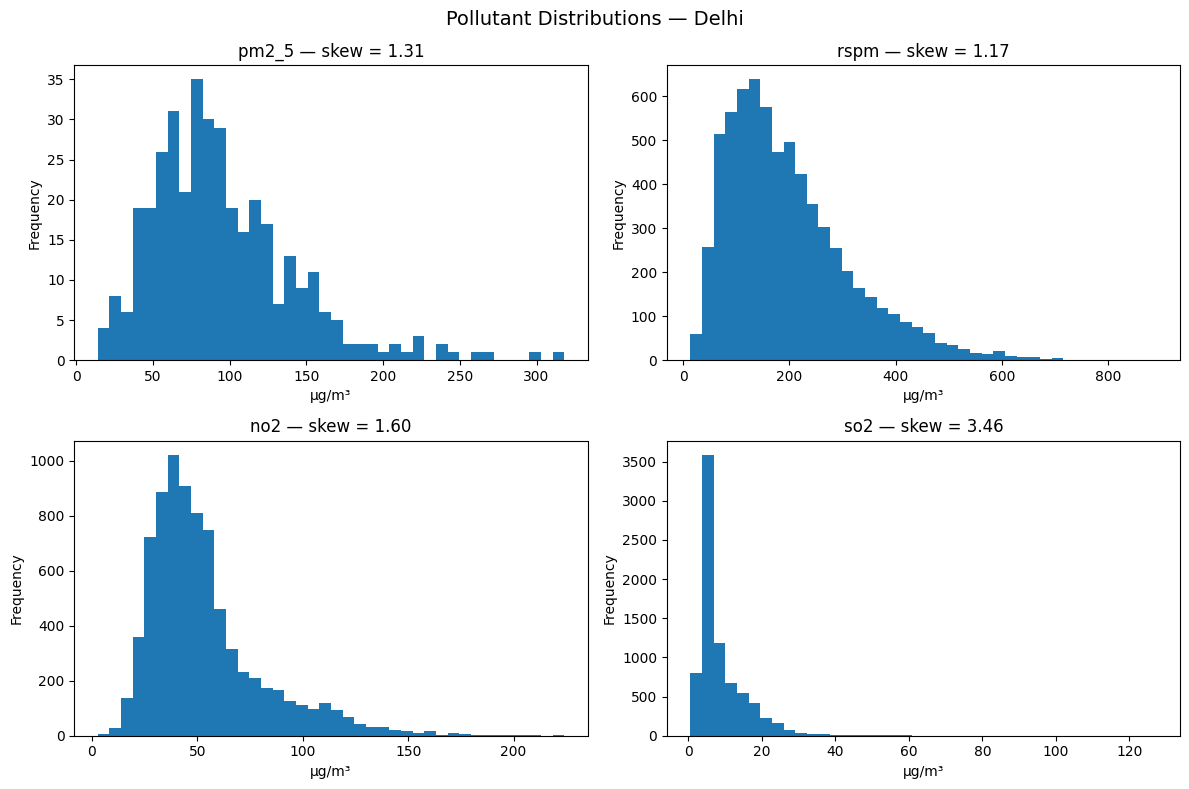

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

pollutant_cols = ["pm2_5", "rspm", "no2", "so2"]

for i, col in enumerate(pollutant_cols):
    data = delhi[col].dropna().values
    skew = compute_skewness(data)
    
    axes[i].hist(data, bins=40)
    axes[i].set_title(f"{col} — skew = {skew:.2f}")
    axes[i].set_xlabel("µg/m³")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Pollutant Distributions — Delhi", fontsize=14)
plt.tight_layout()
plt.savefig("distribution_shapes.png", dpi=150)
plt.show()

### What the histograms show

- All four have a long tail stretching to the right — right skew.
Most days are moderate, but a few extreme days pull the curve out.

- PM2.5 (skew 1.31): most days cluster between 50–100 µg/m³, but some days spike up to 300+. Those are Diwali/crop-burning days we found in Day 3.

- rspm/PM10 (skew 1.17): similar shape to PM2.5 but wider spread, reaching 800+ µg/m³ on extreme days. Confirms Day 1 finding that PM10 had the biggest mean-median gap (25.64).

- NO2 (skew 1.60): tighter cluster around 30–50 µg/m³, but a tail stretching to 200+. Vehicle and industrial emissions create occasional spikes.

- SO2 (skew 3.46): the most extreme shape - almost all days are below 20 µg/m³, but a tiny number of days spike to 120+.
That spike is why kurtosis is 26. Most days SO2 is barely present; on industrial accident days it's catastrophic.

#### What I computed
- **Skewness** — measures how much the distribution leans to one side
- **Kurtosis** — measures how extreme the tail values are

#### Results

| Pollutant | Skewness | Kurtosis |
|-----------|----------|----------|
| PM2.5     | 1.31     | 2.71     |
| PM10      | 1.17     | 1.63     |
| NO2       | 1.60     | 3.28     |
| SO2       | 3.46     | 26.01    |


#### Simple explanation

All four pollutants are right-skewed.
Most days have moderate pollution, but a few extreme days create a long tail on the right side of the histogram.

SO2 is the worst (skew 3.46, kurtosis 26):
Most days SO2 is very low, but on a few days it spikes massively- likely industrial activity or accidents.

NO2 is second (skew 1.60):
PM2.5 and PM10 are similar to each other - both moderately skewed, which matches our Day 1 and Day 3 findings.